<a href="https://colab.research.google.com/github/padminidokka/AI-Based-Dental-Radiograph-Analysis-System/blob/main/SAM_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow opencv-python matplotlib gradio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
image_dir = "/content/drive/MyDrive/Dental/opg_images"
mask_dir = "/content/drive/MyDrive/Dental/masks"

IMG_SIZE = 256

In [ ]:
images = []
masks = []

files = os.listdir(image_dir)

for file in files:

    img_path = os.path.join(image_dir,file)
    mask_name = file.split(".")[0] + "_mask.png"
    mask_path = os.path.join(mask_dir,mask_name)

    if not os.path.exists(mask_path):
        continue

    img = cv2.imread(img_path)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    mask = cv2.imread(mask_path,0)
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    # convert instance masks to binary
    mask[mask > 0] = 1

    images.append(img)
    masks.append(mask)

images = np.array(images)/255.0
masks = np.array(masks)

print("Images loaded:",len(images))

Images loaded: 337


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras import layers,models

def build_unet():

    inputs = layers.Input((256,256,3))

    c1 = layers.Conv2D(32,3,activation="relu",padding="same")(inputs)
    c1 = layers.Conv2D(32,3,activation="relu",padding="same")(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,activation="relu",padding="same")(p1)
    c2 = layers.Conv2D(64,3,activation="relu",padding="same")(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128,3,activation="relu",padding="same")(p2)

    u1 = layers.UpSampling2D()(c3)
    concat1 = layers.Concatenate()([u1,c2])

    c4 = layers.Conv2D(64,3,activation="relu",padding="same")(concat1)

    u2 = layers.UpSampling2D()(c4)
    concat2 = layers.Concatenate()([u2,c1])

    outputs = layers.Conv2D(2,1,activation="softmax")(concat2)

    model = models.Model(inputs,outputs)

    return model

model = build_unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │        194 │ concatenate_1[0]… │
│                     │ 2)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 250,274 (977.63 KB)

 Trainable params: 250,274 (977.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=4
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7520 - loss: 0.6304 - val_accuracy: 0.7608 - val_loss: 0.5479
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7953 - loss: 0.5147 - val_accuracy: 0.7608 - val_loss: 0.5368
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.8161 - loss: 0.4797 - val_accuracy: 0.7608 - val_loss: 0.6854
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7766 - loss: 0.5454 - val_accuracy: 0.7608 - val_loss: 0.6064
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8180 - loss: 0.4656 - val_accuracy: 0.7608 - val_loss: 0.5324
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.8241 - loss: 0.4607 - val_accuracy: 0.7608 - val_loss: 0.5340
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.8166 - loss: 0.4766 - val_accuracy: 0.7611 - val_loss: 0.5483
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.8118 - loss: 0.4763 - val_accuracy: 0.7621 - v

In [ ]:
model.save("/content/drive/MyDrive/Dental/dental_model.h5")

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Dental/dental_model.h5"
)

print("Model loaded successfully")

Model loaded successfully


In [ ]:
image_path = os.path.join(image_dir, files[0])

image = cv2.imread(image_path)
image = cv2.resize(image,(256,256))

input_img = image/255.0
input_img = np.expand_dims(input_img,0)

pred = model.predict(input_img)

mask = np.argmax(pred,axis=-1)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


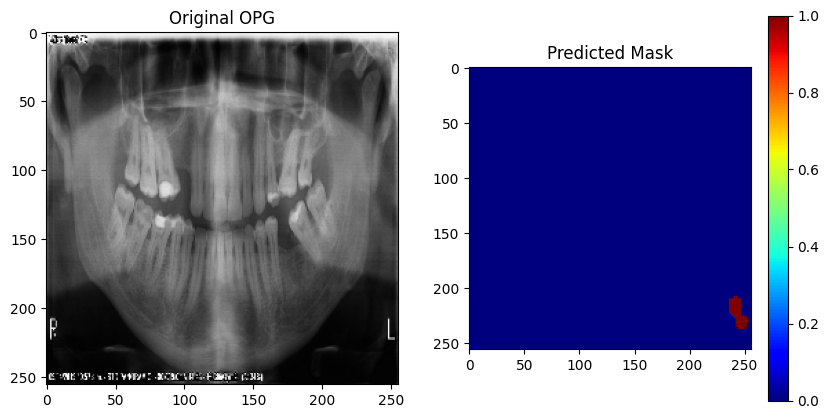

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original OPG")
plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(mask, cmap="jet")
plt.colorbar()

plt.show()

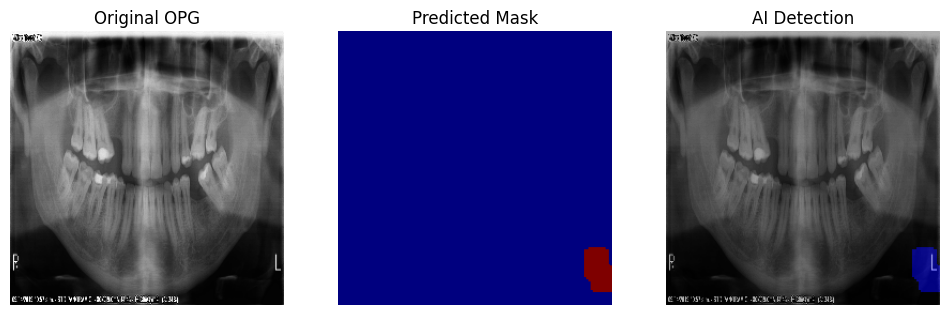

In [ ]:
overlay = image.copy()

# create red mask
color_mask = np.zeros_like(image)
color_mask[mask_binary == 1] = [255,0,0]

# blend
overlay = cv2.addWeighted(image, 0.7, color_mask, 0.5, 0)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Original OPG")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(mask_binary, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("AI Detection")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

In [ ]:
mask_binary = (mask > 0.3).astype(np.uint8)

# enlarge detected region
kernel = np.ones((7,7), np.uint8)
mask_binary = cv2.dilate(mask_binary, kernel, iterations=2)

In [ ]:
num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))

print("Detected tooth regions:", num_labels-1)

Detected tooth regions: 1


In [ ]:
def assign_fdi_numbers_from_mask(mask):

    num_labels, labels = cv2.connectedComponents(mask.astype(np.uint8))

    centers = []

    for i in range(1,num_labels):

        coords = np.column_stack(np.where(labels==i))

        if len(coords)==0:
            continue

        y,x = coords.mean(axis=0)

        centers.append((i,x,y))

    centers = sorted(centers,key=lambda x:x[1])

    fdi_labels = {}

    for i,c in enumerate(centers):

        fdi_labels[c[0]] = i+11

    return fdi_labels

In [ ]:
fdi_labels = assign_fdi_numbers_from_mask(mask)

print("FDI Labels:",fdi_labels)

FDI Labels: {1: 11}
